# Location entropy in NYC and Tokyo Foursquare check-ins

## 1. Objective and executive summary

This analysis asks whether people repeatedly check in at a small set of venues or spread their visits more widely, and whether that pattern differs between the NYC and Tokyo samples or between weekdays and weekends. Only aggregate results are shown.

**Short answer.** Median normalized venue entropy is similar in NYC (**0.853**) and Tokyo (**0.860**). Among users with at least 20 check-ins in each context, median weekend-minus-weekday entropy is **0.058** and **0.059**, respectively. Median normalized category entropy is **0.810** and **0.707**, showing that place and activity diversity are related but not identical.

The analysis identifies three potentially actionable patterns: differences between users are more substantial than the small difference between city medians; most sufficiently observed users show higher weekend venue entropy; and venue diversity does not always imply activity-category diversity. These findings motivate **Context-Aware Discovery**, demonstrated through a companion full-stack prototype. The prototype is a testable product hypothesis, not a validated recommender.


## 2. Dataset and quality checks

Paths are relative to the project, `uv.lock` fixes the environment, and the original data files remain unchanged and ignored by Git. The setup below verifies that both expected source files are present.


In [1]:
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from location_entropy import calculate_location_entropy, prepare_city_data

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "dataset_tsmc2014"
FILES = {
    "NYC": DATA_DIR / "dataset_TSMC2014_NYC.txt",
    "TKY": DATA_DIR / "dataset_TSMC2014_TKY.txt",
}
assert all(path.is_file() for path in FILES.values()), "Download both expected files; see README.md"
CITY_ORDER = list(FILES)

### Loading and preparation

The assignment permits any public spatio-temporal dataset, so I used Foursquare TSMC 2014 check-ins for NYC and Tokyo after the recommended EPFL dataset was unavailable. Each event supplies the user, venue, and timestamp needed for per-user entropy.

The loader applies the headerless Latin-1 TSV schema explicitly, parses timestamps as UTC, and rejects malformed rows, blank required fields, invalid coordinates, and invalid timestamps. Exact duplicates are removed because they would over-count repeated events. Since bare user IDs overlap across files, every user is keyed by `(city, user_id)`.

Local weekday/weekend context comes from `America/New_York` or `Asia/Tokyo`, not the inconsistent supplied offsets. I retain `Home (private)` events because they represent observed routine, but report them only in aggregate; their uneven prevalence between cities remains a measurement and privacy limitation. Venue entropy uses venue IDs, while category entropy uses each event's recorded category ID rather than attempting unnecessary metadata canonicalization.


In [2]:
frames = []
quality_reports = []
for city, path in FILES.items():
    frame, report = prepare_city_data(path, city)
    # Derive context before concatenating columns with different city time zones.
    frame["context"] = np.where(frame["local_time"].dt.dayofweek >= 5, "weekend", "weekday")
    frames.append(frame)
    quality_reports.append(asdict(report))

quality = pd.json_normalize(quality_reports).set_index("city")
expected = {
    "NYC": {"raw_rows": 227_428, "exact_duplicates": 250, "users": 1_083,
            "venues": 38_333, "categories": 251},
    "TKY": {"raw_rows": 573_703, "exact_duplicates": 577, "users": 2_293,
            "venues": 61_858, "categories": 247},
}
for city, checks in expected.items():
    for field, value in checks.items():
        assert quality.loc[city, field] == value, f"Unexpected {city} {field}"
assert (quality[["malformed_rows", "blank_fields", "invalid_coordinate_rows"]] == 0).all().all()
quality[[
    "raw_rows", "clean_rows", "exact_duplicates", "users", "venues", "categories",
    "category_ids", "malformed_rows", "blank_fields", "invalid_coordinate_rows", "home_private_checkins",
    "inconsistent_timezone_rows", "venue_category_conflicts", "venue_coordinate_conflicts",
    "raw_activity.minimum", "raw_activity.median", "raw_activity.maximum",
    "clean_activity.minimum", "clean_activity.median", "clean_activity.maximum",
]]

,raw_rows,clean_rows,exact_duplicates,users,venues,categories,category_ids,malformed_rows,blank_fields,invalid_coordinate_rows,home_private_checkins,inconsistent_timezone_rows,venue_category_conflicts,venue_coordinate_conflicts,raw_activity.minimum,raw_activity.median,raw_activity.maximum,clean_activity.minimum,clean_activity.median,clean_activity.maximum
city,,,,,,,,,,,,,,,,,,,,
NYC,227428,227178,250,1083,38333,251,400,0,0,0,15382,456,337,3484,100,153.0,2697,100,153.0,2693
TKY,573703,573126,577,2293,61858,247,385,0,0,0,3106,27,557,3468,100,173.0,2991,99,173.0,2987


Both files load with the expected row counts. I found and removed exactly **250 NYC** and **577 Tokyo** duplicate rows. No malformed rows, blank fields, or invalid coordinates made it through validation.

The checks also exposed a few less obvious problems. Category IDs and display labels are not one-to-one, some venues have conflicting category or coordinate metadata, and the supplied offsets disagree with the city on **456 NYC** and **27 Tokyo** rows. Those findings support the choices above: use each event's category ID and derive local time from the city rather than trying to repair the venue metadata or trust the supplied offset.

I show activity before and after deduplication separately. In the raw data every user has at least 100 events; after removing duplicates, one Tokyo user has 99. Every entropy result below uses the cleaned data. The next check makes sure the same numerical user ID in two cities is not treated as one person.

In [3]:
data = pd.concat(frames, ignore_index=True)
city_user_count = data[["city", "user_id"]].drop_duplicates().shape[0]
bare_user_count = data["user_id"].nunique()
overlapping_ids = len(set(frames[0]["user_id"]) & set(frames[1]["user_id"]))
assert city_user_count == quality["users"].sum()
assert data["utc_time"].dt.tz is not None
pd.Series({
    "distinct (city, user_id) keys": city_user_count,
    "distinct bare user_id values": bare_user_count,
    "IDs appearing in both city files": overlapping_ids,
    "UTC timezone": str(data["utc_time"].dt.tz),
    "NYC local timezone": str(frames[0]["local_time"].dt.tz),
    "Tokyo local timezone": str(frames[1]["local_time"].dt.tz),
})

distinct (city, user_id) keys                   3376
distinct bare user_id values                    2293
IDs appearing in both city files                1083
UTC timezone                                     UTC
NYC local timezone                  America/New_York
Tokyo local timezone                      Asia/Tokyo
dtype: object

## 3. Methodology

For user $u$, let $n_u(i)$ be their check-ins at venue $i$ and $N_u$ their total check-ins:

$$p_u(i)=n_u(i)/N_u,\qquad H_u=-\sum_i p_u(i)\log_2 p_u(i).$$

Four check-ins split A, A, A, B give probabilities 0.75 and 0.25 and entropy of about 0.811 bits. Repeating one venue gives zero entropy; distributing visits evenly raises it.

Users have different observed venue counts, so I also report $H_{u,norm}=H_u/\log_2(K_u)$ for $K_u$ unique venues, defined as zero when $K_u\leq1$. This measures how evenly recorded visits are spread across a user's observed set. It does not measure distance, dwell time, purchases, demand, or personality, and normalization does not remove observation bias.

`calculate_location_entropy` performs the grouped calculation with vectorized pandas operations. Its small interface accepts the data, one or more group columns, and a location column; it validates required keys and returns observation count, unique-location count, raw entropy, and normalized entropy. Unit tests cover hand-calculated cases, composite groups, and malformed inputs.


In [4]:
venue_entropy = calculate_location_entropy(
    data, group_cols=["city", "user_id"], location_col="venue_id"
)
category_entropy = calculate_location_entropy(
    data, group_cols=["city", "user_id"], location_col="category_id"
)
metrics = venue_entropy.merge(
    category_entropy, on=["city", "user_id"], suffixes=("_venue", "_category"), validate="one_to_one"
)
assert len(metrics) == city_user_count
assert metrics["normalized_entropy_venue"].between(-1e-12, 1 + 1e-12).all()
assert metrics["normalized_entropy_category"].between(-1e-12, 1 + 1e-12).all()

venue_summary = metrics.groupby("city").agg(
    users=("user_id", "size"),
    median_checkins=("observation_count_venue", "median"),
    median_unique_venues=("unique_location_count_venue", "median"),
    q25_raw_entropy=("entropy_venue", lambda x: x.quantile(.25)),
    median_raw_entropy=("entropy_venue", "median"),
    q75_raw_entropy=("entropy_venue", lambda x: x.quantile(.75)),
    q25_normalized_entropy=("normalized_entropy_venue", lambda x: x.quantile(.25)),
    median_normalized_entropy=("normalized_entropy_venue", "median"),
    q75_normalized_entropy=("normalized_entropy_venue", lambda x: x.quantile(.75)),
).round(3)
venue_summary

,users,median_checkins,median_unique_venues,q25_raw_entropy,median_raw_entropy,q75_raw_entropy,q25_normalized_entropy,median_normalized_entropy,q75_normalized_entropy
city,,,,,,,,,
NYC,1083,153.0,76.0,4.668,5.348,6.031,0.781,0.853,0.915
TKY,2293,173.0,80.0,4.720,5.487,6.076,0.780,0.860,0.920


## 4. Core city comparison

The first thing I notice is how similar the normalized distributions are. The median is **0.853 in NYC** (IQR **0.781–0.915**) and **0.860 in Tokyo** (IQR **0.780–0.920**). Tokyo has slightly higher raw entropy and more unique venues, but most of the two distributions overlap.

This suggests that a typical user's recorded visits are spread across much of their own venue set rather than being dominated by one place. The 0.007 difference between city medians is not enough to rank the cities. The samples can differ in activity, Foursquare adoption, venue taxonomy, and who chose to check in. I therefore focus on medians, IQRs, and the full distributions rather than a mean or a city winner.

**Figure 1 — normalized venue entropy distributions.**

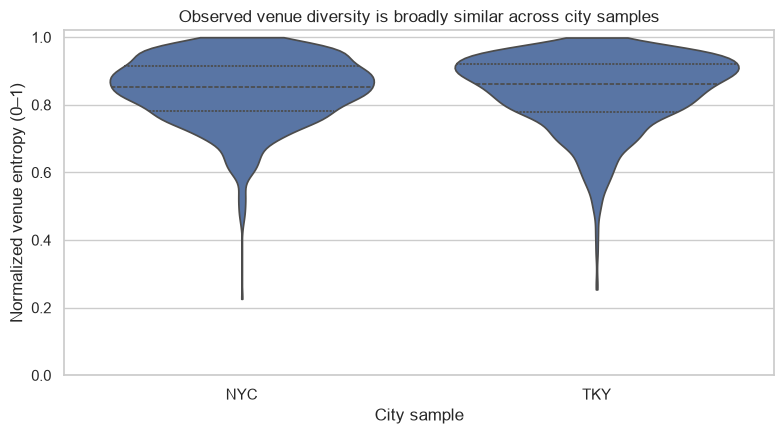

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.violinplot(data=metrics, x="city", y="normalized_entropy_venue", inner="quart", cut=0, ax=ax)
ax.set(title="Observed venue diversity is broadly similar across city samples",
       xlabel="City sample", ylabel="Normalized venue entropy (0–1)", ylim=(0, 1.02))
plt.tight_layout()
plt.show()

## 5. Activity and observation bias

Normalized entropy is moderately lower among users with more check-ins and higher among users with more unique venues. The count distributions are skewed, so Figure 2 uses log-scaled axes and hexagonal bins to show density without displaying identifiable users. The relationship confirms that activity and venue counts should accompany entropy rather than treating it as a complete user summary.

**Figure 2 — normalized entropy against check-in and unique-venue counts.**


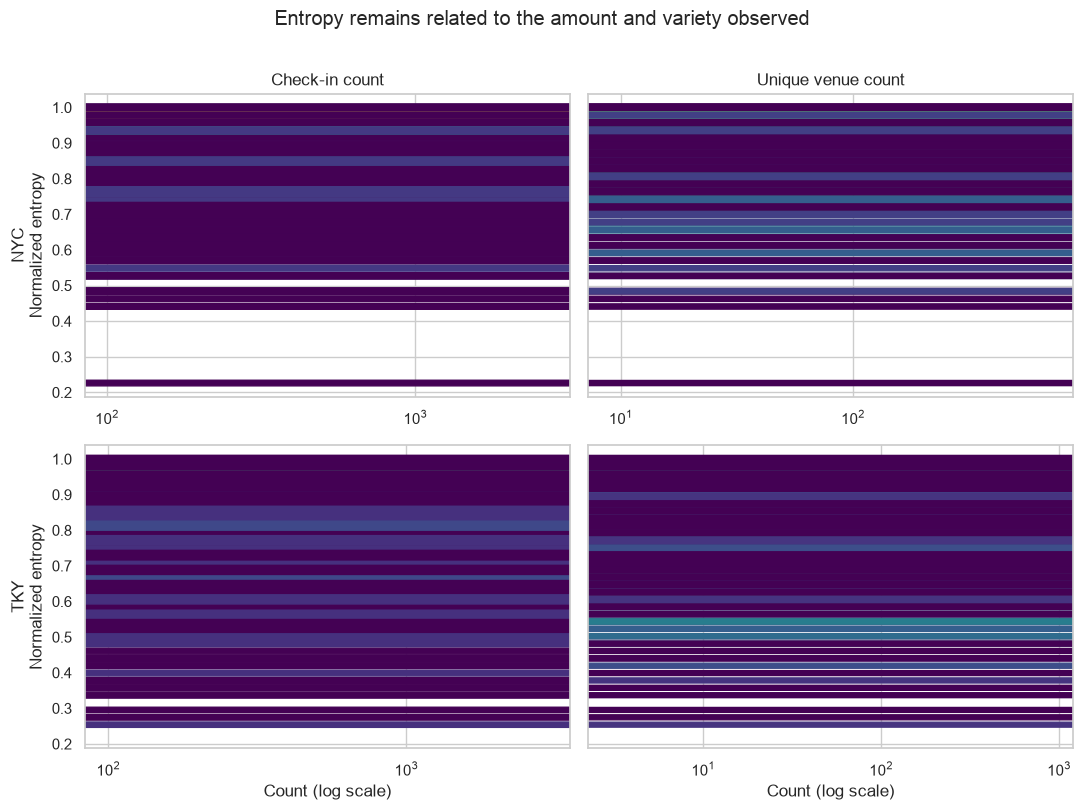

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for row, city in enumerate(CITY_ORDER):
    subset = metrics[metrics["city"] == city]
    axes[row, 0].hexbin(subset["observation_count_venue"], subset["normalized_entropy_venue"],
                        gridsize=32, mincnt=1, bins="log", cmap="viridis")
    axes[row, 1].hexbin(subset["unique_location_count_venue"], subset["normalized_entropy_venue"],
                        gridsize=32, mincnt=1, bins="log", cmap="viridis")
    axes[row, 0].set_ylabel(f"{city}\nNormalized entropy")
    axes[row, 0].set_xscale("log")
    axes[row, 1].set_xscale("log")
axes[0, 0].set_title("Check-in count")
axes[0, 1].set_title("Unique venue count")
for ax in axes[-1]: ax.set_xlabel("Count (log scale)")
fig.suptitle("Entropy remains related to the amount and variety observed", y=1.01)
plt.tight_layout()
plt.show()

## 6. Weekdays and weekends

I calculate venue entropy separately in local weekday and weekend time. To avoid comparing very small context samples, I retain only users with at least **20 cleaned check-ins in each context** and report exclusions. The threshold is pragmatic rather than a guarantee of reliability.

For each eligible user, $\Delta H_{norm}=H_{weekend}-H_{weekday}$; a positive value means their recorded weekend visits are more diverse. Because this is a paired question, I summarize each city's user-level differences with the median and IQR.


In [7]:
context_entropy = calculate_location_entropy(
    data, ["city", "user_id", "context"], "venue_id"
)
context_wide = context_entropy.pivot(
    index=["city", "user_id"], columns="context",
    values=["observation_count", "normalized_entropy"],
).fillna(0)
eligible_mask = (
    (context_wide[("observation_count", "weekday")] >= 20)
    & (context_wide[("observation_count", "weekend")] >= 20)
)
temporal = context_wide[eligible_mask].copy()
temporal["delta"] = (
    temporal[("normalized_entropy", "weekend")]
    - temporal[("normalized_entropy", "weekday")]
)

rows = []
for city in CITY_ORDER:
    delta = temporal.loc[city, "delta"]
    total = int((context_wide.reset_index()["city"] == city).sum())
    rows.append({
        "city": city,
        "eligible_users": len(delta),
        "excluded_users": total - len(delta),
        "q25_delta": delta.quantile(.25),
        "median_delta": delta.median(),
        "q75_delta": delta.quantile(.75),
        "share_positive": (delta > 0).mean(),
    })
temporal_summary = pd.DataFrame(rows).set_index("city")
temporal_summary.round(3)


,eligible_users,excluded_users,q25_delta,median_delta,q75_delta,share_positive
city,,,,,,
NYC,1019,64,0.020,0.058,0.116,0.885
TKY,2142,151,0.016,0.059,0.131,0.854


The threshold leaves **1,019 NYC** users and **2,142 Tokyo** users; it excludes 64 and 151, respectively. Median weekend-minus-weekday entropy is **+0.058 in NYC** (IQR **0.020–0.116**) and **+0.059 in Tokyo** (IQR **0.016–0.131**). The difference is positive for **88.5%** of eligible NYC users and **85.4%** of eligible Tokyo users.

Most eligible users therefore have a broader or more even set of recorded weekend visits. This is descriptive: different activities or check-in choices could produce the pattern, so it does not establish that weekends cause exploration.

**Figure 3 — weekend entropy minus weekday entropy for the same user.**


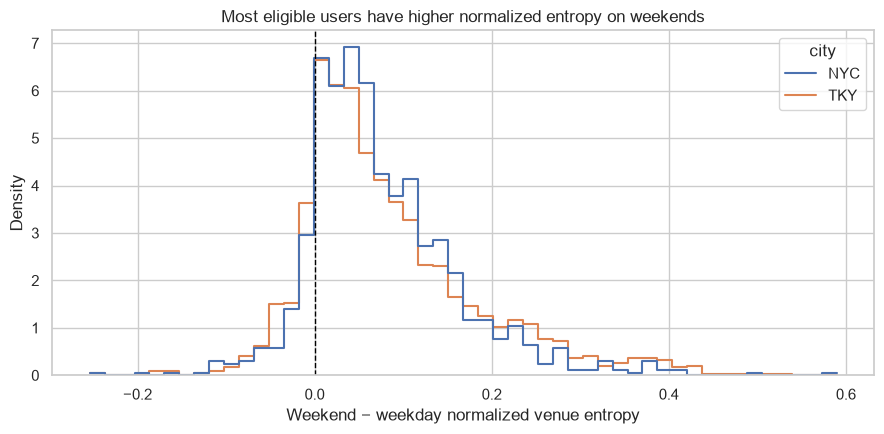

In [8]:
delta_plot = temporal["delta"].rename("delta").reset_index()
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(data=delta_plot, x="delta", hue="city", bins=50, stat="density",
             common_norm=False, element="step", fill=False, ax=ax)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set(title="Most eligible users have higher normalized entropy on weekends",
       xlabel="Weekend − weekday normalized venue entropy", ylabel="Density")
plt.tight_layout()
plt.show()

## 7. Venue diversity and activity diversity

A person can visit many coffee shops or train stations without visiting many kinds of places. I therefore repeat the calculation using each check-in's `category_id`, separating venue variety from activity variety.

Median normalized category entropy is **0.810 in NYC** and **0.707 in Tokyo**. Its rank correlation with venue entropy is **0.897 in NYC** and **0.728 in Tokyo**. The measures are related but not interchangeable: especially in Tokyo, a varied venue set can still represent a narrower activity set.

This is an analytical distinction, not a preference claim. It supports keeping profile-level venue and activity diversity distinct. In the prototype, aggregate candidate novelty and profile-specific category familiarity are separate ranking inputs; neither is a venue entropy score, and this analysis does not show that a person wants either kind of novelty.

**Figure 4 — normalized venue entropy versus normalized category entropy.**


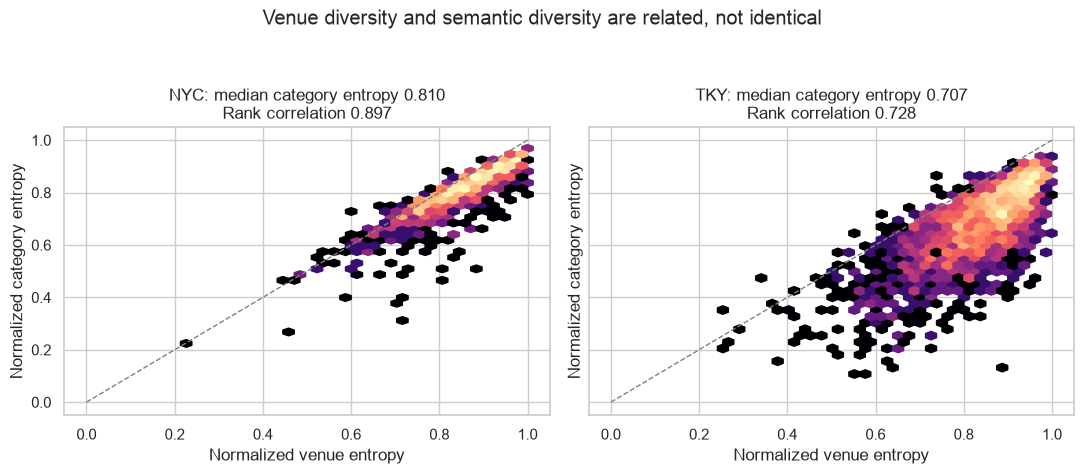

In [9]:
category_summary = metrics.groupby("city").agg(
    median_category_entropy=("normalized_entropy_category", "median"),
)
category_summary["rank_correlation"] = metrics.groupby("city").apply(
    lambda group: group["normalized_entropy_venue"].rank().corr(
        group["normalized_entropy_category"].rank()
    ),
    include_groups=False,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, city in zip(axes, CITY_ORDER):
    subset = metrics[metrics["city"] == city]
    summary = category_summary.loc[city]
    ax.hexbin(
        subset["normalized_entropy_venue"],
        subset["normalized_entropy_category"],
        gridsize=30,
        mincnt=1,
        bins="log",
        cmap="magma",
    )
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax.set(
        title=(
            f"{city}: median category entropy {summary['median_category_entropy']:.3f}"
            f"\nRank correlation {summary['rank_correlation']:.3f}"
        ),
        xlabel="Normalized venue entropy",
        ylabel="Normalized category entropy",
    )
fig.suptitle("Venue diversity and semantic diversity are related, not identical", y=1.05)
plt.tight_layout()
plt.show()


## 8. Insights and product opportunities

The table separates computed evidence or cautious interpretation from possible needs and implementation opportunities. The middle and right columns are hypotheses, not results.

| Evidence or interpretation | Potential user or business need | Product opportunity |
|---|---|---|
| User variation exceeds the city-median difference | Personalization without geographic stereotyping | Context-Aware Discovery |
| Weekend entropy is higher for most eligible users | Recommendations that reflect changing context | Weekend discovery adjustment |
| Venue and category diversity differ | Choose between a new place and a new kind of activity | Separate profile-diversity and candidate signals |
| Metrics vary with observed-history volume | Avoid premature personalization | Confidence-aware cold start |
| Interpretation: concentrated histories may be sensitive | Transparency and control over inferred behavior | Privacy/predictability summary |

Four concepts follow with different strength. **Context-Aware Discovery** is the selected primary concept because it connects all principal findings while making uncertainty and explicit control part of the behavior. **Weekend Discovery Mode** is a useful adjustment inside it, but context alone is too narrow for a standalone product. **Merchant Audience Insights** could aggregate broad patterns, but check-ins are not footfall, purchases, or demand. A **Privacy and Predictability Summary** could offer transparency, but entropy alone is not a privacy-risk score.

## 9. Selected concept and product hypothesis

> People may receive more useful venue suggestions when a transparent candidate-novelty signal is adjusted cautiously using observed profile diversity, reliable temporal context, category familiarity, and an explicit user preference.

This is the hypothesis, not an observed preference. A deterministic prototype demonstrates one possible implementation:

- **Profile history:** normalized venue and category entropy describe diversity in observed check-ins; they are not venue scores.
- **Candidate novelty:** inverse aggregate historical popularity indicates “less commonly visited in this sample,” not newly opened or higher quality.
- **Category familiarity:** categories present in the synthetic profile history remain a distinct, inspectable adjustment.
- **Reliable positive weekend difference:** modestly raise applied discovery on weekends.
- **Sparse history:** regress the inferred signal toward neutral and rely more on explicit preference.
- **Every profile:** explicit preference dominates the inferred default.

Entropy stays attached to the synthetic profile. It is not a personality label or a claim about intent, home, work, venue quality, freshness, or current desirability.

> **Required claim boundary.** These patterns motivate product hypotheses. They do not show that high-entropy users prefer novel recommendations, that weekends cause exploration, or that entropy-aware ranking improves engagement.


## 10. Prototype walkthrough and architecture

The companion **Discovery Mode** begins with a three-step evidence bridge:

1. normalized venue and category entropy describe diversity in a synthetic profile’s observed history;
2. that profile-level signal, confidence, and a modest reliable weekend difference adjust an explicit discovery choice;
3. the resulting deterministic ranking demonstrates a product hypothesis—it does not prove recommendation quality.

A reviewer selects an anonymous synthetic profile, weekday/weekend context, and “What feels right today?” choice. Controls rerank immediately. Every result has a pseudonymous label because the source data contain no venue names. Each candidate shows city, source category, rounded aggregate historical support, a plain-language reason, and expandable score components.

![Discovery Mode selected interface](../apps/frontend/public/prototype/discovery-mode.png)

![Prototype architecture](../docs/prototype-architecture.svg)

```text
Browser
  ↓
Next.js + React + committed notebook presentation artifact
  ↓ JSON/HTTP for Discovery Mode only
FastAPI + Pydantic
  ↓
Deterministic ranking policy + safe aggregate candidate catalog
  ↓ offline generation only
Historical NYC and Tokyo check-ins
```

Example request:

```json
{"profile_id":"routine","context":"weekend","discovery_mode":"balanced","limit":6}
```

Example response excerpt:

```json
{
  "profile":{"id":"routine","venue_entropy":0.72,"category_entropy":0.58,"confidence":0.90},
  "context":"weekend",
  "applied_discovery":0.5803,
  "recommendations":[{
    "id":"candidate-nyc-004",
    "label":"NYC · Concert Hall · Candidate 04",
    "category":"Concert Hall",
    "aggregate_popularity_percentile":57,
    "aggregate_novelty":0.43,
    "category_familiarity":0,
    "reason":"A category outside this synthetic profile’s familiar history, with a modest weekend adjustment."
  }],
  "disclaimer":"Illustrative discovery ranking over privacy-safe historical candidates; not a trained or validated recommender or current place guide."
}
```

The ranking policy maps explicit choices to 0.20, 0.50, or 0.80. Explicit intent contributes 70% of applied discovery; confidence-adjusted profile venue/category entropy contributes 30%; weekend context adds `confidence × weekend_delta`. Baseline relevance is an illustrative transform of aggregate popularity. Candidate novelty is its inverse. Category familiarity is a separate binary profile adjustment. A bounded curve keeps familiar mode relevance-led while allowing the “something new” choice to change order visibly. Generated candidate ID breaks ties. The policy is illustrative and deterministic, not learned.

The offline catalog groups actual historical venue records, excludes private-home and other sensitive or residential categories, requires at least 30 check-ins and 15 distinct visitors, and selects eight candidates per city across the eligible popularity range. Counts are rounded to groups of five. It emits no source venue IDs, user IDs, exact coordinates, timestamps, or trajectories. Because the source has no venue names, labels are generated as city, category, and candidate number rather than invented proper names.

“New” means new to the selected synthetic profile or less commonly visited in this historical sample. The source check-ins are from 2012–2013, so candidates are not current recommendations and may no longer exist. The API loads only the committed safe catalog; the frontend build never reads raw check-ins. Exact generation, validation, local run, and test commands are in [`README.md`](../README.md).


## 11. Evaluation and safeguards

A future randomized experiment must answer:

> **Does adapting recommendation novelty with these signals improve user outcomes relative to the baseline ranker?**

- **Control:** baseline relevance ranking.
- **Treatment:** context-aware ranking over the same candidate pool with the same explicit override.
- **Primary metric:** save or selection rate per recommendation impression.
- **Secondary metrics:** category discovery rate, catalog coverage, and return engagement.
- **Guardrails:** hides/dismissals, early exits, repeated suggestions, travel distance, latency, and sparse-history performance.
- **Segments:** baseline entropy, confidence, context, city, and explicit discovery choice.

Offline entropy correlations do not answer this validation question. Before launch, the feature would also need data minimization, expiry, user controls, threshold calibration, monitoring for differential harm, and strict exclusion of home/work inference and private-home coordinates.


## 12. Limitations, production path, and conclusion

- Voluntary check-ins reflect both movement and the decision to report it; they do not measure dwell time, purchases, demand, or footfall.
- Entropy remains dependent on observation count and observation process. Normalization improves comparability but cannot remove sampling bias.
- These 2012–2013 users are not representative of NYC or Tokyo populations or necessarily of current behavior. City differences are descriptive, not causal or cultural effects.
- Conflicting venue metadata and category taxonomies add uncertainty, and the 20-event context threshold should be revisited for a deployed use case.
- Private-home records are sensitive and unevenly represented, so production use would require stricter data governance than this aggregate analysis.

### Production path

The repository provides explicit schema and input validation, composite user keys, duplicate removal, separate loading and metric modules, deterministic analysis, and unit tests. At larger scale, validated events could be partitioned in Parquet and aggregated with Polars or Spark. A scheduled pipeline should monitor schema drift, missing values, duplicate spikes, timezone anomalies, metadata conflicts, and metric distributions. Metric definitions and thresholds should be versioned for traceability.

### Conclusion: evidence, hypothesis, validation

1. **What the historical data show:** city medians are similar; within-city variation is larger; most sufficiently observed users have higher weekend venue entropy; venue and category diversity differ; and all metrics remain tied to what was observed.
2. **What hypothesis follows:** venue novelty and activity novelty might be more useful when adjusted cautiously by confidence, reliable context, and an explicit user preference rather than city stereotypes.
3. **What evidence is still required:** a randomized comparison must establish whether this behavior improves saves or selections without worsening dismissals, repetition, distance, latency, sparse-history outcomes, privacy, or user trust.

The historical analysis motivates the question. It does not validate the prototype or establish present-day recommendation quality.

### References

- Yang, D., Zhang, D., Zheng, V. W., & Yu, Z. (2015). Modeling User Activity Preference by Leveraging User Spatial Temporal Characteristics in LBSNs. *IEEE Transactions on Systems, Man, and Cybernetics: Systems*, 45(1), 129–142.
- Starmer, J. (StatQuest). [*Entropy (for data science) Clearly Explained*](https://www.youtube.com/watch?v=YtebGVx-Fxw). YouTube.
